# CV-QEC: Numerical Simulations

This notebook reproduces the key figures from:

**"Discrete-variable assisted error correction of continuous-variable quantum information"**  
Negin Razian, En-Jui Chang, and Hoi-Kwan Lau

## Structure
1. Displacement error channel — Equation (1)
2. Filter function after qubit measurement — Equation (7)  
3. Optimal α and variance suppression — Figure 2
4. Variance vs qudit dimension d — Figure 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

## 1. Displacement Error Channel

The random displacement error transforms a CV state $\hat{\rho}_{cv}$ as:

$$\mathcal{E}(\hat{\rho}_{cv}) = \int P(\beta) \hat{D}(\beta) \hat{\rho}_{cv} \hat{D}^\dagger(\beta) d^2\beta$$

where the displacement distribution is Gaussian:

$$P(\beta) = G(\beta_q, \sigma) G(\beta_p, \sigma), \quad G(x,\sigma) \equiv \frac{e^{-x^2/\sigma^2}}{\sqrt{\pi}\sigma}$$

We characterize the noise by $\sigma$ — the standard deviation of the displacement.

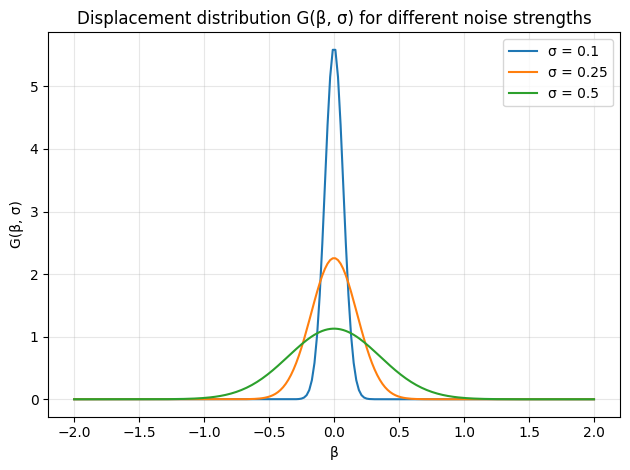

In [5]:
# Disapacement distribution from Equation (2)
def G(x, sigma):
    return np.exp(-x**2 / sigma**2)/(np.sqrt(np.pi) * sigma)

def P(beta_q, beta_p, sigma):
    return G(beta_q, sigma) * G(beta_p, sigma)

# Plot for different sigma values 
beta = np.linspace(-2 ,2, 200)
sigmas = [0.1, 0.25, 0.5]

plt.Figure(figsize=(8, 4))

for sigma in sigmas:
    plt.plot(beta, G(beta, sigma), label=f'σ = {sigma}')

plt.xlabel('β')
plt.ylabel('G(β, σ)')
plt.title('Displacement distribution G(β, σ) for different noise strengths')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Filter Function After Qubit Measurement — Equation (7)

After encoding, displacement error, and decoding, the qubit is measured 
in the $\{|\pm Y\rangle\}$ basis.

Upon outcome $|\pm Y\rangle$, the displacement distribution is modified by a filter:

$$P(\beta_p) \rightarrow G(\beta_p, \sigma)(1 \pm \sin(4\alpha\beta_p))$$

The modified distribution has mean:

$$\bar{\beta}_\pm = \pm 2\alpha\sigma^2 e^{-4\alpha^2\sigma^2}$$

The correction is to displace back by $\bar{\beta}_\pm$.

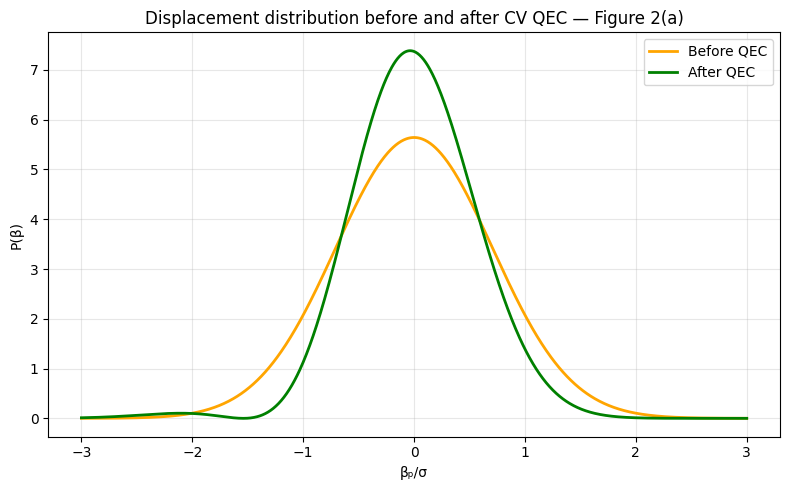

Variance before QEC: 0.005000
Variance after QEC:  0.003161
Reduction: 36.8%


In [7]:
# Filter function after qubit measurement — Figure 2(a)
def filtered_distribution(beta_p, sigma, alpha, sign=+1):
    """Modified displacement distribution after qubit measurement."""
    return G(beta_p, sigma) * (1 + sign * np.sin(4 * alpha * beta_p))

def beta_mean(sigma, alpha, sign=+1):
    """Mean of the corrected distribution — analytical formula."""
    return sign * 2 * alpha * sigma**2 * np.exp(-4 * alpha**2 * sigma**2)

# Parameters from paper
sigma = 0.1
alpha_opt = 1 / (2 * np.sqrt(2) * sigma)   # optimal alpha from paper

beta_p = np.linspace(-3*sigma, 3*sigma, 1000)

# Before QEC
P_before = G(beta_p, sigma)

# After QEC — |+Y⟩ outcome
P_after = filtered_distribution(beta_p, sigma, alpha_opt, sign=+1)
beta_bar = beta_mean(sigma, alpha_opt, sign=+1)

# Corrected distribution — shift back by beta_bar
P_corrected = filtered_distribution(beta_p + beta_bar, sigma, alpha_opt, sign=+1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(beta_p/sigma, P_before,    color='orange', label='Before QEC', linewidth=2)
plt.plot(beta_p/sigma, P_corrected, color='green',  label='After QEC', linewidth=2)
plt.xlabel('βₚ/σ')
plt.ylabel('P(β)')
plt.title('Displacement distribution before and after CV QEC — Figure 2(a)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print variance reduction
var_before = sigma**2 / 2
var_after  = (1 - 1/np.e) * sigma**2 / 2
print(f"Variance before QEC: {var_before:.6f}")
print(f"Variance after QEC:  {var_after:.6f}")
print(f"Reduction: {(1 - var_after/var_before)*100:.1f}%")

## 3. Optimal Conditional Displacement Strength — Figure 2(b)

The performance depends on the choice of $\alpha$. 
The optimal value that minimizes the corrected variance is:

$$\alpha_{opt} = \frac{1}{2\sqrt{2}\sigma}$$

We verify this numerically by computing the variance for different $\alpha$.

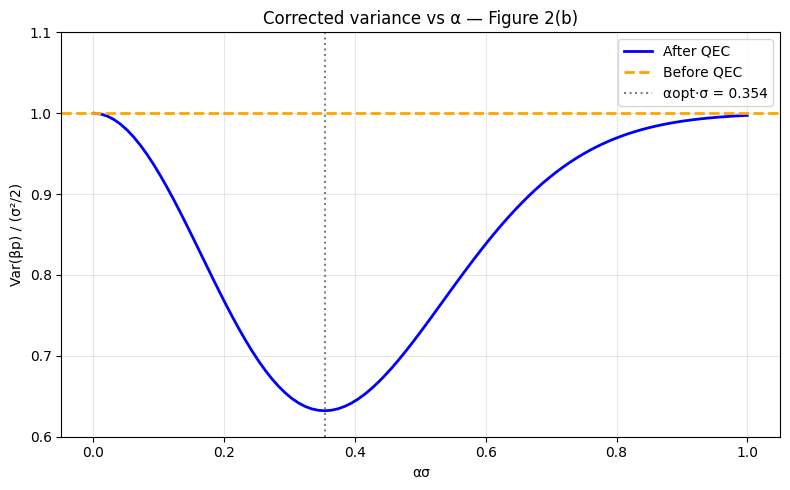

Optimal α·σ = 0.3536
Minimum variance ratio = 0.6321


In [8]:
# Variance vs alpha — Figure 2(b)
def variance_after_qec(alpha, sigma):
    """Compute corrected variance numerically."""
    beta_p = np.linspace(-6*sigma, 6*sigma, 2000)
    db = beta_p[1] - beta_p[0]
    
    # Filtered distribution for +Y outcome
    P_filt = filtered_distribution(beta_p, sigma, alpha, sign=+1)
    N_plus = np.sum(P_filt) * db   # normalisation
    
    # Mean
    beta_bar = np.sum(beta_p * P_filt) * db / N_plus
    
    # Corrected distribution
    P_corr = filtered_distribution(beta_p + beta_bar, sigma, alpha, sign=+1)
    
    # Variance
    var = np.sum(beta_p**2 * P_corr) * db / np.sum(P_corr * db)
    return var

sigma = 0.1
alphas = np.linspace(0.01, 1.0/sigma, 100)
variances = [variance_after_qec(a, sigma) / (sigma**2/2) for a in alphas]

alpha_opt = 1 / (2 * np.sqrt(2) * sigma)

plt.figure(figsize=(8, 5))
plt.plot(alphas * sigma, variances, color='blue', linewidth=2, label='After QEC')
plt.axhline(y=1.0, color='orange', linestyle='--', linewidth=2, label='Before QEC')
plt.axvline(x=alpha_opt * sigma, color='gray', linestyle=':', linewidth=1.5, label=f'αopt·σ = {alpha_opt*sigma:.3f}')
plt.xlabel('ασ')
plt.ylabel('Var(βp) / (σ²/2)')
plt.title('Corrected variance vs α — Figure 2(b)')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim([0.6, 1.1])
plt.tight_layout()
plt.show()

print(f"Optimal α·σ = {alpha_opt*sigma:.4f}")
print(f"Minimum variance ratio = {min(variances):.4f}")